In [3]:
%load_ext autoreload
%autoreload 2
import pandas as pd

data = pd.read_csv("symptoms_flat.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from experiment_map import symptom_standard
symptomg = data.groupby("Symptom")

new_data = []
seen_sym = {}
for i, k in data.iterrows():
    all_i = k["Symptom"].split(" / ")
    for ii in all_i:
        kcopy = k.copy()
        kcopy["Symptom"] = ii
        
        if i not in seen_sym:
            seen_sym[i] = []
        # print(symptom_standard[ii])
        if symptom_standard[ii] in seen_sym[i]:
            continue
        seen_sym[i].append(symptom_standard[ii])
        kcopy["symptom_class"] = symptom_standard[ii] if ii in symptom_standard else ii
        new_data.append(kcopy)
df = pd.DataFrame(new_data)

# data["symptom_class"] = data["Symptom"].apply(lambda x: symptom_standard[x] if x in symptom_standard else x)

# for i, k in symptomg:
#     # print(i, len(k))
#     all_i = i.split(" / ")
#     for j in all_i:
#         if j in symptom_standard or j in symptom_standard.values():
#             continue
#             # print(" ", symptom_standard[j])
#         else:
#             print(" ", j, len(k))
#             for ii, iii in k.iterrows():
#                 print(iii)

In [5]:
import numpy as np
symclassg = df.groupby("symptom_class")
all_reactions = list(set(df["reaction_split"]))

mat = []
for i, k in symclassg:
    # print(i, len(k))
    this_arr = np.zeros(len(all_reactions))
    vcs = k.value_counts("reaction_split")
    for vc in vcs.index:
        this_arr[all_reactions.index(vc)] = vcs[vc]
    mat.append(this_arr)

Aldehyde reductive amination
Chlorination
SNAr ether synthesis
Esterification
Bromination
Nitro to amino
Bromo N-alkylation
Hydroamination
Other separation
Acid to acid chloride
Amide Schotten-Baumann
Bromo Suzuki-type coupling
Ring closing olefin metathesis
Unrecognized
Carbamate Schotten-Baumann
Bromo Suzuki coupling
Alcohol to aldehyde oxidation
Ketone to alcohol reduction
Racemization
N-Boc deprotection
Amide hydrolysis
Alkene hydrogenation
Ester hydrolysis


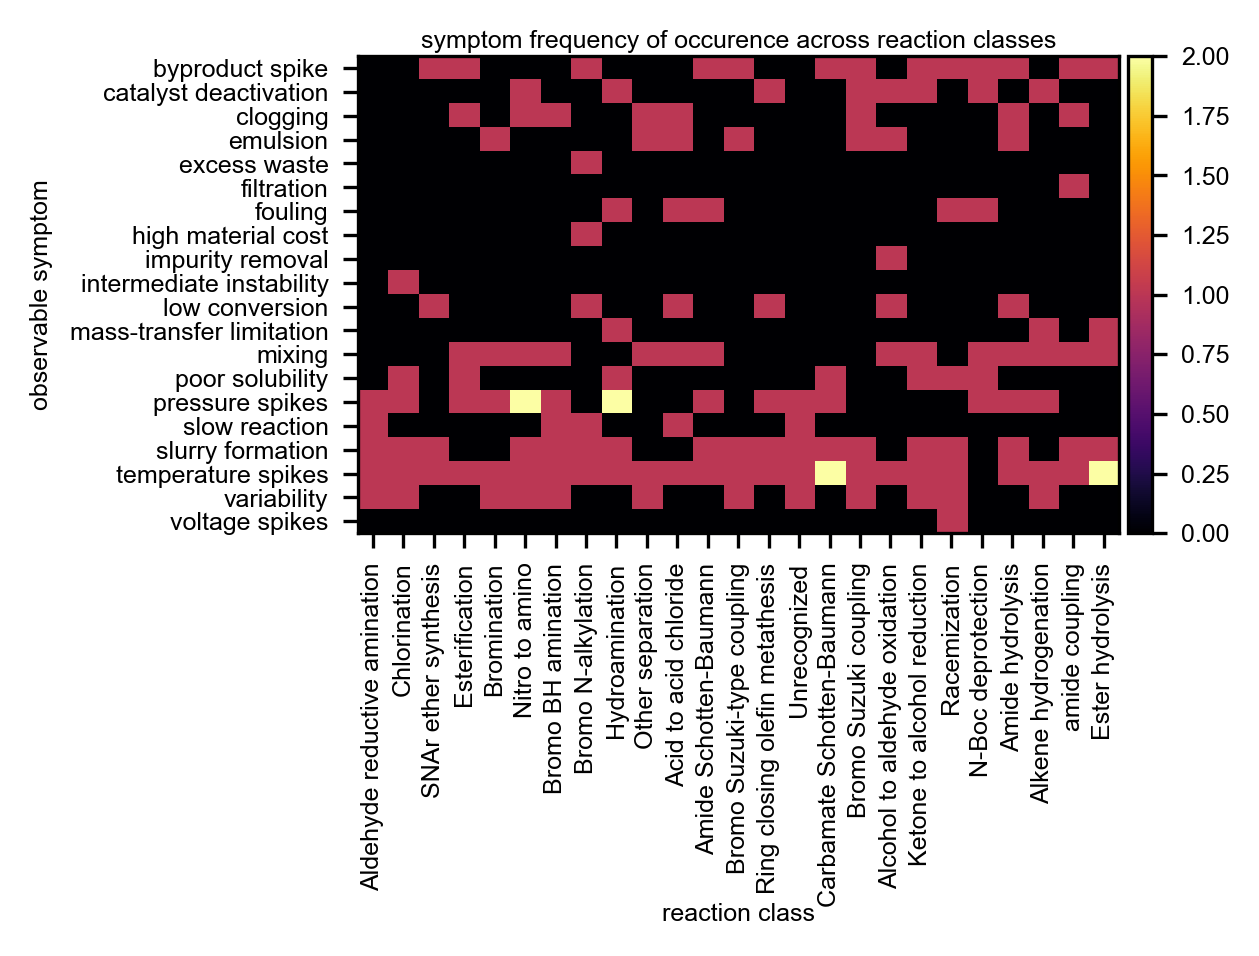

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

fig,ax = plt.subplots(figsize=(4,3), dpi=300)
all_reactions_rename = {
    "Carboxylic acid + amine condensation": "amide coupling",
    "Bromo Buchwald-Hartwig amination": "Bromo BH amination",
}
for k in all_reactions:
    if k not in all_reactions_rename:
        print(k)

im = ax.imshow(mat, aspect="auto", cmap="inferno")
ax.set_yticks(range(len(symclassg)))
ax.set_yticklabels([i for i, k in symclassg])
ax.set_xticks(range(len(all_reactions)))
ax.set_xticklabels([all_reactions_rename.get(k, k) for k in all_reactions], rotation=90)
ax.set_ylabel("observable symptom")
ax.set_xlabel("reaction class", labelpad=-1)
ax.set_title("symptom frequency of occurence across reaction classes", fontsize=6, pad=2)
cbar = plt.colorbar(im, pad=.01)
fig.subplots_adjust(left=0.275, right=1.03, top=0.965, bottom=0.435)
plt.savefig("plots/symptom_reaction_heatmap.png", dpi=300, bbox_inches=None, pad_inches=0.01)
# plt.show()

In [8]:
import numpy as np
from experiment_map import exp_map
symclassg = df.groupby("symptom_class")
all_reactions = list(set(df["reaction_split"]))

mat = []
seen = {}

# for i, k in symclassg:
#     print(i, len(k))
fixed_hs = []
experiment_class = []
for ii, kk in df.iterrows():
    fixed_hypothesis = []
    for ijj,jj in enumerate(kk["Hypothesis"].replace("\n","").strip().split(", ")):
        for jjj in jj.split(" "):
            for jjjj in jjj.split(","):
                if "_" not in jjjj:
                    continue
                fprcl = jjjj.replace(".","")
                if fprcl == "gas_evolution_or_mass_transfer_management, pressure_or_gas_headspace_optimization, solvent_change_for_solubility, temperature_setpoint_or_temperature_ramp_optimization":
                    fprcl = "gas_evolution_or_mass_transfer_management"
                if fprcl == "custom_or_novel_reactor_design, improved_mixing_or_impeller_design, pressure_or_gas_headspace_optimization, temperature_setpoint_or_temperature_ramp_optimization":
                    fprcl = "gas_evolution_or_mass_transfer_management"
                fixed_hypothesis.append(fprcl)

    fexp = kk["Experiment"].replace("\n", " ")
    experiment_class.append(", ".join(sorted(exp_map[fexp])))
    fixed_hs.append(", ".join(sorted(fixed_hypothesis)))
df["fixed_hypothesis"] = fixed_hs
df["experiment_class"] = experiment_class


In [9]:
import networkx as nx

dg = nx.DiGraph()


dfg_rc = df.groupby("reaction_split")
seen = {}
all_exp = set()
labels = {}
clade = {}
for i, k in dfg_rc:
    dg.add_node(i)
    labels[i] = i
    clade[i] = "reaction_class"
    print(i, len(k))
    df_symg = k.groupby("symptom_class")
    for ii, kk in df_symg:
        dg.add_node(ii)
        labels[ii] = ii
        dg.add_edge(i, ii)
        clade[ii] = "symptom"
        print(" ", ii, len(kk))
        df_fixh = kk.groupby("fixed_hypothesis")
        for i1, j1 in df_fixh:
            move = []
            # dg.add_node(i1)
            # clade[i1] = "hypothesis"
            # labels[i1] = i1
            # dg.add_edge(ii, i1)
            # for chg in ["custom_or_novel_reactor_design", "improved_mixing_or_impeller_design"]
            # if len(kk) > 1:
            print("  ", i1, len(j1))
            df_expg = j1.groupby("experiment_class")
            for ijj, jj in df_expg:
                for ex in ijj.split(", "):
                    all_exp.add(ex)
                print("   ", ijj.split(", "), len(jj))
                for ex in ijj.split(", "):
                    dg.add_node(ex)
                    labels[ex] = ex
                    clade[ex] = "experiment"
                    dg.add_edge(ii, ex)
                # if len(jj) > 1:
                # for i2, j2 in jj.iterrows():
                    # if i2 in seen:
                        # continue
                    # seen[i2] = True
                    # print("!    ", j2["Symptom"])
                    # print("!    ", j2["Experiment"])
                    # print("!    ", j2["Observation"])
                    # print("!    ", j2["additional_details"])

                # print()

Acid to acid chloride 7
  clogging 1
   clogging_or_fouling_mitigation, custom_or_novel_reactor_design, improved_mixing_or_impeller_design 1
    ['change_mixer_design', 'introduce_cleaning_protocol', 'long_term_stability_test'] 1
  emulsion 1
   change_of_additive, solvent_change_for_solubility, solvent_system_optimization_or_cosolvent_addition 1
    ['change_additive', 'change_solvent', 'in_line_monitoring', 'long_term_stability_test', 'pressure_drop_monitoring'] 1
  fouling 1
   clogging_or_fouling_mitigation, custom_or_novel_reactor_design, improved_mixing_or_impeller_design 1
    ['change_mixer_design', 'introduce_cleaning_protocol', 'long_term_stability_test'] 1
  low conversion 1
   optimization_of_acid_or_base_stoichiometry, optimization_of_reagent_stoichiometry, solvent_change_for_solubility 1
    ['change_equivalents', 'change_solvent', 'factorial_doe', 'pilot_scale_validation'] 1
  mixing 1
   change_of_addition_order_or_feed_profile, improved_mixing_or_impeller_design, solve

In [10]:
def spread_columns(dg, pos, selected_depths=None, top=1.0, bottom=0.0, left=0.0, right=1.0, ignored_depths=None):
    # Group by your existing traversal depth (best column key in this graph)
    by_depth = {}
    for n in dg.nodes:
        d = dg.nodes[n].get("depth")
        by_depth.setdefault(d, []).append(n)

    y_min, y_max = bottom, top
    x_min, x_max = left, right
    new_pos = dict(pos)
    x_range = x_max - x_min
    x_div = x_range*1 / len(by_depth)


    for d, nodes in by_depth.items():
        # print(d, len(nodes))
        if ignored_depths is not None and d in ignored_depths:
            continue
        if selected_depths is not None and d not in selected_depths:
            continue
        if len(nodes) <= 1:
            continue

        # Keep Graphviz relative order, only stretch vertically
        nodes_sorted = sorted(nodes, key=lambda n: pos[n][1], reverse=True)
        ys = np.linspace(y_max, y_min, len(nodes_sorted))
        offset = False
        # if len(nodes) > 60:
        #     stagger = True
        #     x_offset = x_div/4
        #     coin = 1
        # else:
        #     stagger = False
        #     x_offset = 0.0
        #     coin = 0

        for n, y in zip(nodes_sorted, ys):
            # x = pos[n][0]
            x = x_min + x_div*d
            # print(d, x)
            new_pos[n] = (x, float(y))
            # if stagger:
            #     new_pos[n] = (x_offset+ x + x_offset*coin, float(y))
            #     coin *= -1
            # else:
            #     if dg.nodes[n]["depth"] >= 5:
            #         new_pos[n] = (x - x_offset, float(y))
    

    return new_pos


In [11]:
node_colors = {}
node_labels = {}
for i in clade:
    if clade[i] == "reaction_class":
        node_colors[i] = "#4E7AA7"
        node_labels[i] = all_reactions_rename.get(labels[i], labels[i]).replace("_", " ")
        dg.nodes[i]["depth"] = 0
    elif clade[i] == "symptom":
        node_colors[i] = "#E15759"
        node_labels[i] = labels[i].replace("_", " ")
        dg.nodes[i]["depth"] = 1
    elif clade[i] == "hypothesis":
        node_colors[i] = "green"
        node_labels[i] = ""
        dg.nodes[i]["depth"] = 2
    elif clade[i] == "experiment":
        node_colors[i] = "#59A14E"
        node_labels[i] = labels[i].replace("_", " ")
        dg.nodes[i]["depth"] = 2

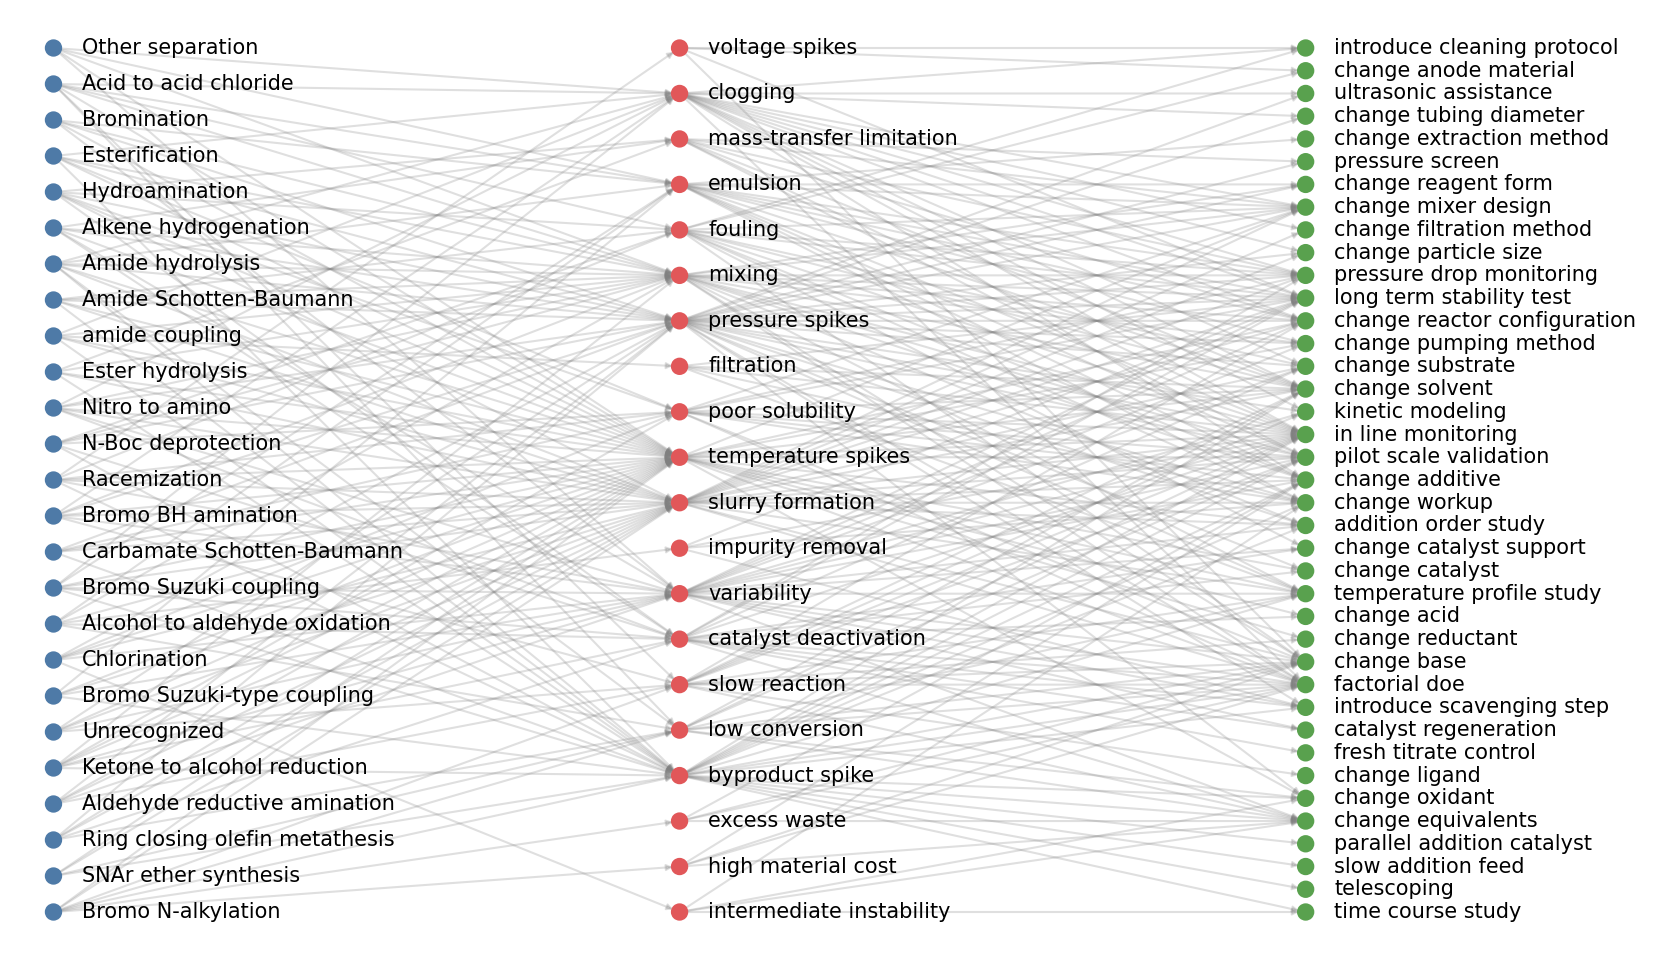

In [12]:
pos = nx.nx_agraph.graphviz_layout(dg, prog="dot", args="-Grankdir=LR")
max_pos_y = max(y for x, y in pos.values())
min_pos_y = min(y for x, y in pos.values())
yrange = max_pos_y - min_pos_y
max_pos_x = max(x for x, y in pos.values())
min_pos_x = min(x for x, y in pos.values())
pos_xrange = max_pos_x - min_pos_x
pos_top_pad = yrange * 0.025/1.25
pos_bottom_pad = yrange * 0.025/1.25
pos_left_pad = pos_xrange * 0.025/2
pos_right_pad = pos_xrange * -0.025*6
# print(min_pos_x)
pos = spread_columns(dg, pos, top=max_pos_y - pos_top_pad, bottom=min_pos_y + pos_bottom_pad, left=min_pos_x, right=max_pos_x)

fig,ax = plt.subplots(figsize=(6,3), dpi=300)
nx.draw_networkx_nodes(dg, pos, ax=ax, node_size=10, node_color=[node_colors[i] for i in dg.nodes()])
nx.draw_networkx_edges(dg, pos, ax=ax, width=0.5, node_size=10, arrowsize=3, alpha=0.25, edge_color="gray")

label_pos = {n: (x+25/3, y) for n, (x, y) in pos.items()}
nx.draw_networkx_labels(dg, label_pos, ax=ax, labels=node_labels, font_size=5, horizontalalignment="left", verticalalignment="center")


ax.set_xlim((min_pos_x-pos_left_pad, max_pos_x+pos_right_pad))
ax.set_ylim((min_pos_y, max_pos_y))
ax.margins(0)

ax.set_axis_off()
fig.subplots_adjust(left=0.0, right=0.9, top=1, bottom=0)

plt.savefig("plots/knowledge_graph.png", dpi=300, bbox_inches=None, pad_inches=0.01)
# plt.show()

In [462]:
print(len(all_exp), sorted(all_exp))

39 ['addition_order_study', 'catalyst_regeneration', 'change_acid', 'change_additive', 'change_anode_material', 'change_base', 'change_catalyst', 'change_catalyst_support', 'change_equivalents', 'change_extraction_method', 'change_filtration_method', 'change_ligand', 'change_mixer_design', 'change_oxidant', 'change_particle_size', 'change_pumping_method', 'change_reactor_configuration', 'change_reagent_form', 'change_reductant', 'change_solvent', 'change_substrate', 'change_tubing_diameter', 'change_workup', 'factorial_doe', 'fresh_titrate_control', 'in_line_monitoring', 'introduce_cleaning_protocol', 'introduce_scavenging_step', 'kinetic_modeling', 'long_term_stability_test', 'parallel_addition_catalyst', 'pilot_scale_validation', 'pressure_drop_monitoring', 'pressure_screen', 'slow_addition_feed', 'telescoping', 'temperature_profile_study', 'time_course_study', 'ultrasonic_assistance']


In [107]:
print(data["step_when_to_move_on"][0])

The optimal acid-equiv and water % are fixed and reproducible on >= 5 g runs; conversion > 95 % confirmed by HPLC.


In [ ]:
sol_map = {
    "optimization_of_acid_or_base_stoichiometry; optimization_of_reagent_stoichiometry": "reagent_stoichiometry",
    "optimization_of_reagent_stoichiometry": "reagent_stoichiometry",
    "optimization_of_catalyst_loading": "reagent_stoichiometry",
    "optimization_of_acid_or_base_stoichiometry": "reagent_stoichiometry",
    "optimization_of_catalyst_loading; optimization_of_reagent_stoichiometry": "reagent_stoichiometry",
    "optimization_of_reagent_stoichiometry; optimization_of_acid_or_base_stoichiometry": "reagent_stoichiometry",
    "optimization_of_acid_or_base_stoichiometry; change_of_addition_order_or_feed_profile": "reagent_stoichiometry",
    "optimization_of_acid_or_base_stoichiometry; automatic pH-control; optimization_of_acid_or_base_stoichiometry": "reagent_stoichiometry",
    "change_of_addition_order_or_feed_profile; optimization_of_reagent_stoichiometry": "reagent_stoichiometry",
    "optimization_of_reagent_stoichiometry; solvent_change_for_safety_or_green_chemistry": "reagent_stoichiometry",
    "optimization_of_reagent_stoichiometry; change_of_addition_order_or_feed_profile": "reagent_stoichiometry",
    "improved_quench_or_neutralization; optimization_of_reagent_stoichiometry": "reagent_stoichiometry",
    "improved_in_process_control_or_analytical_method; optimization_of_catalyst_loading": "reagent_stoichiometry",

    "solvent_change_for_solubility; change_of_base": "reagent_identity",
    "replacement_of_costly_or_low_purity_reagent": "reagent_identity",
    "replacement_of_unstable_or_impure_reagent": "reagent_identity",
    "change_of_acid; change_of_base": "reagent_identity",
    "change_of_catalyst_or_ligand_identity": "reagent_identity",
    "change_of_base; change_of_acid": "reagent_identity",
    "change_of_additive; solvent_change_for_solubility": "reagent_identity",
    "replacement_of_unstable_or_impure_reagent; replacement_of_costly_or_low_purity_reagent; change_of_base": "reagent_identity",
    "change_of_acid; condition_change_to_reduce_or_remove_process_hazard": "reagent_identity",
    "replacement_of_unstable_or_impure_reagent; change_of_primary_reagent": "reagent_identity",
    "reagent_change_to_reduce_waste_or_increase_green_score; replacement_of_costly_or_low_purity_reagent": "reagent_identity",
    "replacement_of_unstable_or_impure_reagent; replacement_of_costly_or_low_purity_reagent": "reagent_identity",
    "change_of_catalyst_or_ligand_identity; optimization_of_catalyst_loading": "reagent_identity",
    "optimization_of_catalyst_loading; change_of_catalyst_or_ligand_identity": "reagent_identity",
    "change_of_base; solvent_change_for_solubility": "reagent_identity",
    "change_of_primary_reagent; replacement_of_unstable_or_impure_reagent; reagent_change_to_reduce_waste_or_increase_green_score": "reagent_identity",
    "change_of_primary_reagent; replacement_of_unstable_or_impure_reagent": "reagent_identity",
    "change_of_reductant_or_reduction_protocol": "reagent_identity",
    "replacement_of_costly_or_low_purity_reagent; replacement_of_unstable_or_impure_reagent; reagent_change_to_reduce_waste_or_increase_green_score": "reagent_identity",
    "change_of_reductant_or_reduction_protocol; replacement_of_costly_or_low_purity_reagent": "reagent_identity",
    "condition_change_to_reduce_or_remove_process_hazard; replacement_of_unstable_or_impure_reagent": "reagent_identity",
    "change_of_catalyst_or_ligand_identity; replacement_of_unstable_or_impure_reagent": "reagent_identity",
    "change_of_catalyst_or_ligand_identity; replacement_of_costly_or_low_purity_reagent": "reagent_identity",
    "replacement_of_unstable_or_impure_reagent; replacement_of_costly_or_low_purity_reagent; change_of_primary_reagent": "reagent_identity",
    "change_of_base": "reagent_identity",
    "solvent_change_for_solubility; solvent_change_for_reactivity; change_of_additive; change_of_base": "reagent_identity",
    "change_of_reductant_or_reduction_protocol; change_of_oxidant_or_oxidation_protocol": "reagent_identity",
    "change_of_oxidant_or_oxidation_protocol; solvent_change_for_safety_or_green_chemistry": "reagent_identity",
    "replacement_of_costly_or_low_purity_reagent; replacement_of_unstable_or_impure_reagent":"reagent_identity",
    "pressure_or_gas_headspace_optimization; condition_change_to_reduce_or_remove_process_hazard":"reagent_identity",
    "optimization_of_reagent_stoichiometry; change_of_reductant_or_reduction_protocol":"reagent_identity",
    "<change_of_base>":"reagent_identity",
    "change_of_additive": "reagent_identity",
    "replacement_of_unstable_or_impure_reagent; improved_impurity_purge_or_byproduct_control": "reagent_identity",
    "replacement_of_costly_or_low_purity_reagent; solvent_change_for_safety_or_green_chemistry": "reagent_identity",
    "change_of_additive; optimization_of_catalyst_loading; optimization_of_reagent_stoichiometry": "reagent_identity",
    "optimization_of_catalyst_loading; replacement_of_costly_or_low_purity_reagent": "reagent_identity",
    "improved_heat_transfer_or_temperature_control_hardware; condition_change_to_reduce_or_remove_process_hazard": "reagent_identity",
    "change_of_base; optimization_of_acid_or_base_stoichiometry":"reagent_identity",
    "change_of_acid; temperature_setpoint_or_temperature_ramp_optimization":"reagent_identity",
    "optimization_of_reagent_stoichiometry; replacement_of_costly_or_low_purity_reagent":"reagent_identity",
    "change_of_base; change_of_reductant_or_reduction_protocol":"reagent_identity",
    "replacement_of_costly_or_low_purity_reagent; replacement_of_unstable_or_impure_reagent; change_of_primary_reagent":"reagent_identity",
    "change_of_oxidant_or_oxidation_protocol; change_of_reductant_or_reduction_protocol":"reagent_identity",
    "change_of_base; change_of_acid; optimization_of_acid_or_base_stoichiometry":"reagent_identity",
    "change_of_base; change_of_additive":"reagent_identity",
    "change_of_additive; improved_impurity_purge_or_byproduct_control":"reagent_identity",
    "reagent_change_to_reduce_waste_or_increase_green_score":"reagent_identity",
    "replacement_of_unstable_or_impure_reagent; change_of_additive":"reagent_identity",
    "optimization_of_catalyst_loading; change_of_additive":"reagent_identity",
    "change_of_additive; change_of_base":"reagent_identity",
    "optimization_of_catalyst_loading; replacement_of_unstable_or_impure_reagent":"reagent_identity",
    "phase_behavior_or_biphasic_system_optimization; change_of_additive":"reagent_identity",
    "change_of_additive; clogging_or_fouling_mitigation":"reagent_identity",
    "condition_change_to_reduce_or_remove_process_hazard":"reagent_identity",
    "condition_change_to_reduce_or_remove_process_hazard; thermal_runaway_mitigation_or_quench_safety_modification": "reagent_identity",
    "change_of_additive; crystallization_solvent_or_antisolvent_optimization": "reagent_identity",
    "optimization_of_acid_or_base_stoichiometry; change_of_additive": "reagent_identity",
    "improved_quench_or_neutralization; change_of_additive; improved_impurity_purge_or_byproduct_control": "reagent_identity",
    "optimization_of_inert_atmosphere_or_deoxygenation; change_of_additive": "reagent_identity",
    "condition_change_to_reduce_or_remove_process_hazard; gas_evolution_or_mass_transfer_management": "reagent_identity",


    "solvent_change_for_solubility": "solvent_system",
    "phase_behavior_or_biphasic_system_optimization": "solvent_system",
    "<solvent_change_for_solubility>": "solvent_system",
    "solvent_change_for_safety_or_green_chemistry; solvent_change_for_solubility": "solvent_system",
    "phase_behavior_or_biphasic_system_optimization; solvent_change_for_solubility": "solvent_system",
    "solvent_change_for_solubility; solvent_change_for_safety_or_green_chemistry": "solvent_system",
    "solvent_system_optimization_or_cosolvent_addition": "solvent_system",
    "solvent_change_for_solubility; solvent_system_optimization_or_cosolvent_addition": "solvent_system",
    "solvent_change_for_solubility; solvent_change_for_reactivity": "solvent_system",
    "crystallization_solvent_or_antisolvent_optimization; solvent_change_for_solubility": "solvent_system",
    "solvent_change_for_solubility; solvent_change_for_reactivity; solvent_change_for_safety_or_green_chemistry": "solvent_system",
    "phase_behavior_or_biphasic_system_optimization; solvent_system_optimization_or_cosolvent_addition":"solvent_system",
    "solvent_change_for_safety_or_green_chemistry":"solvent_system",
    "solvent_change_for_solubility; solvent_system_optimization_or_cosolvent_addition; phase_behavior_or_biphasic_system_optimization": "solvent_system",
    "crystallization_solvent_or_antisolvent_optimization": "solvent_system",
    "solvent_system_optimization_or_cosolvent_addition; improved_mixing_or_impeller_design": "solvent_system",
    "slurry_handling_or_particle_size_optimization; solvent_change_for_solubility": "solvent_system",
    "solvent_change_for_solubility; solvent_change_for_safety_or_green_chemistry; improved_impurity_purge_or_byproduct_control": "solvent_system",
    "solvent_system_optimization_or_cosolvent_addition; phase_behavior_or_biphasic_system_optimization": "solvent_system",
    "<solvent_system_optimization_or_cosolvent_addition>": "solvent_system",
    "crystallization_nucleation_or_seed_control": "solvent_system",
    "slurry_handling_or_particle_size_optimization; clogging_or_fouling_mitigation": "solvent_system",
    "phase_behavior_or_biphasic_system_optimization; change_of_addition_order_or_feed_profile": "solvent_system",
    "solvent_change_for_reactivity; solvent_change_for_safety_or_green_chemistry": "solvent_system",
    "slurry_handling_or_particle_size_optimization; improved_mixing_or_impeller_design": "solvent_system",
    "solvent_system_optimization_or_cosolvent_addition; optimization_of_reagent_stoichiometry": "solvent_system",
    "improved_impurity_purge_or_byproduct_control; drying_or_isolation_process_optimization; crystallization_solvent_or_antisolvent_optimization": "solvent_system",
    "improved_mixing_or_impeller_design; slurry_handling_or_particle_size_optimization": "solvent_system",
    "crystallization_nucleation_or_seed_control; drying_or_isolation_process_optimization": "solvent_system",
    "batch_to_flow_or_flow_process_implementation; phase_behavior_or_biphasic_system_optimization":"solvent_system",
    "improved_mixing_or_impeller_design; phase_behavior_or_biphasic_system_optimization":"solvent_system",
    "crystallization_solvent_or_antisolvent_optimization; drying_or_isolation_process_optimization":"solvent_system",
    "improved_quench_or_neutralization; solvent_change_for_solubility":"solvent_system",
    "improved_quench_or_neutralization":"solvent_system",

    "improved_mixing_or_impeller_design; pressure_or_gas_headspace_optimization": "reactor",
    "gas_evolution_or_mass_transfer_management; improved_mixing_or_impeller_design": "reactor",
    "optimization_of_inert_atmosphere_or_deoxygenation; pressure_or_gas_headspace_optimization": "reactor",
    "pressure_or_gas_headspace_optimization; gas_evolution_or_mass_transfer_management; custom_or_novel_reactor_design": "reactor",
    "batch_to_flow_or_flow_process_implementation; change_of_addition_order_or_feed_profile": "reactor",
    "optimization_of_inert_atmosphere_or_deoxygenation; improved_quench_or_neutralization": "reactor",
    "pressure_or_gas_headspace_optimization; thermal_runaway_mitigation_or_quench_safety_modification": "reactor",
    "gas_evolution_or_mass_transfer_management; pressure_or_gas_headspace_optimization": "reactor",
    "improved_mixing_or_impeller_design; clogging_or_fouling_mitigation": "reactor",
    "hold_time_or_residence_time_optimization": "reactor",
    "pressure_or_gas_headspace_optimization": "reactor",
    "gas_evolution_or_mass_transfer_management": "reactor",
    "clogging_or_fouling_mitigation; improved_mixing_or_impeller_design": "reactor",
    "batch_to_flow_or_flow_process_implementation; continuous_process_intensification":"reactor",
    "improved_in_process_control_or_analytical_method":"reactor",
    "improved_impurity_purge_or_byproduct_control; tolerance_of_reagent_or_feed_impurities":"reactor",
    "custom_or_novel_reactor_design; batch_to_flow_or_flow_process_implementation":"reactor",
    "change_of_addition_order_or_feed_profile; gas_evolution_or_mass_transfer_management":"reactor",
    "improved_photochemical_reactor_or_light_delivery; improved_mixing_or_impeller_design":"reactor",
    "clogging_or_fouling_mitigation; custom_or_novel_reactor_design":"reactor",
    "<improved_mixing_or_impeller_design>":"reactor",
    "improved_impurity_purge_or_byproduct_control":"reactor",
    "improved_quench_or_neutralization; drying_or_isolation_process_optimization":"reactor",
    "custom_or_novel_reactor_design; optimization_of_inert_atmosphere_or_deoxygenation":"reactor",
    "optimization_of_inert_atmosphere_or_deoxygenation":"reactor",
    "custom_or_novel_reactor_design; improved_mixing_or_impeller_design; improved_heat_transfer_or_temperature_control_hardware":"reactor",
    "improved_in_process_control_or_analytical_method; process_modeling_or_digital_twin_guided_change": "reactor",
    "clogging_or_fouling_mitigation": "reactor",
    "improved_quench_or_neutralization; improved_impurity_purge_or_byproduct_control": "reactor",
    "drying_or_isolation_process_optimization": "reactor",
    "process_modeling_or_digital_twin_guided_change":"reactor",
    "<improved_in_process_control_or_analytical_method>":"reactor",
    "improved_mixing_or_impeller_design; temperature_setpoint_or_temperature_ramp_optimization; gas_evolution_or_mass_transfer_management":"reactor",
    "feedstock_or_supplier_variability_management; tolerance_of_reagent_or_feed_impurities":"reactor",
    "drying_or_isolation_process_optimization; improved_quench_or_neutralization":"reactor",
    "improved_impurity_purge_or_byproduct_control; improved_in_process_control_or_analytical_method": "reactor",
    "improved_in_process_control_or_analytical_method; pressure_or_gas_headspace_optimization": "reactor",
    "process_modeling_or_digital_twin_guided_change; improved_in_process_control_or_analytical_method": "reactor",
    "pressure_or_gas_headspace_optimization; gas_evolution_or_mass_transfer_management":"reactor",
    "improved_mixing_or_impeller_design; custom_or_novel_reactor_design": "reactor",
    "batch_to_flow_or_flow_process_implementation; custom_or_novel_reactor_design": "reactor",
    "change_of_addition_order_or_feed_profile": "reactor", 
    "improved_mixing_or_impeller_design": "reactor",
    "improved_mixing_or_impeller_design; custom_or_novel_reactor_design; improved_heat_transfer_or_temperature_control_hardware": "reactor",


    "temperature_setpoint_or_temperature_ramp_optimization": "temperature",
    "hold_time_or_residence_time_optimization; temperature_setpoint_or_temperature_ramp_optimization": "temperature",
    "temperature_setpoint_or_temperature_ramp_optimization; pressure_or_gas_headspace_optimization": "temperature",
    "gas_evolution_or_mass_transfer_management; thermal_runaway_mitigation_or_quench_safety_modification": "temperature",
    "temperature_setpoint_or_temperature_ramp_optimization; hold_time_or_residence_time_optimization": "temperature",
    "thermal_runaway_mitigation_or_quench_safety_modification": "temperature",

    "improved_heat_transfer_or_temperature_control_hardware": "temperature",
    "thermal_runaway_mitigation_or_quench_safety_modification; improved_heat_transfer_or_temperature_control_hardware": "temperature",
    "temperature_setpoint_or_temperature_ramp_optimization; thermal_runaway_mitigation_or_quench_safety_modification": "temperature",
    "temperature_setpoint_or_temperature_ramp_optimization; improved_heat_transfer_or_temperature_control_hardware; thermal_runaway_mitigation_or_quench_safety_modification": "temperature",
    "improved_heat_transfer_or_temperature_control_hardware; custom_or_novel_reactor_design": "temperature",
    "improved_mixing_or_impeller_design; improved_heat_transfer_or_temperature_control_hardware": "temperature",
    "batch_to_flow_or_flow_process_implementation; improved_heat_transfer_or_temperature_control_hardware": "temperature",
    "improved_heat_transfer_or_temperature_control_hardware; thermal_runaway_mitigation_or_quench_safety_modification": "temperature",
    "process_modeling_or_digital_twin_guided_change; temperature_setpoint_or_temperature_ramp_optimization": "temperature",
    "process_modeling_or_digital_twin_guided_change; thermal_runaway_mitigation_or_quench_safety_modification": "temperature",
    "temperature_setpoint_or_temperature_ramp_optimization; improved_heat_transfer_or_temperature_control_hardware": "temperature",

    "improved_quench_or_neutralization; thermal_runaway_mitigation_or_quench_safety_modification": "temperature",
    "thermal_runaway_mitigation_or_quench_safety_modification; improved_quench_or_neutralization": "temperature",
    "temperature_setpoint_or_temperature_ramp_optimization; change_of_addition_order_or_feed_profile": "temperature",
    "temperature_setpoint_or_temperature_ramp_optimization; improved_quench_or_neutralization": "temperature",
    "phase_behavior_or_biphasic_system_optimization; change_of_additive": "temperature",
    "change_of_addition_order_or_feed_profile; temperature_setpoint_or_temperature_ramp_optimization":"temperature",


           }

accounted = set(["0.1", "10.1", "40.1", "65.1", "100.1", "135.1", "216.1", "221.1", "246.1", "356.1", "56.2", "6.2", \
                 "81.2", "151.2", "212.2", "232.2", "262.2", "307.2", "337.2", "342.2", "388.2", "393.2", "92.3"])
wfsg = data.groupby("workflow_step")
for i,ig in wfsg:
    # print(i, len(ig["ontology_solutions"].uniq
    uni = set()
    # print(ig)
    # break
    for ii in ig["ontology_solutions"].unique():
        if ii in sol_map:
            v = sol_map[ii]
        else:
            v = ii
        # if v not in uni:
            # print("  ", v)
        uni.add(v)
    # print(ig.columns)
    # break
    for ii,kk in ig.iterrows():
        if sol_map[kk["ontology_solutions"]] == "reagent_stoichiometry" and i == 3.0:
            row_index = str(ii)+"."+str(int(i))
            if row_index in accounted:
                continue
            print(kk["reaction_split"], row_index, "\n", kk["ontology_solutions"], sol_map[kk["ontology_solutions"]], "\n",
                kk["workflow_step_title"], "\n",
                kk["step_action"], "\n",
                kk["step_reasoning"])
            print()
    print("  ", i, len(uni))
    print()

   1.0 5

   2.0 5

Ester hydrolysis 92.3 
 optimization_of_acid_or_base_stoichiometry; optimization_of_reagent_stoichiometry reagent_stoichiometry 
 Stoichiometry optimisation (minimise waste & side-products) 
 Use the minimum base equivalents that still give full conversion (typically 2 equiv LiOH or 1.5 equiv NaOH). Record the exact equivalents and monitor pH to avoid excess alkalinity. 
 Excess base drives side-reactions such as bis-acid formation (entry 2302) and increases waste handling costs.

Esterification 117.3 
 optimization_of_reagent_stoichiometry; optimization_of_acid_or_base_stoichiometry reagent_stoichiometry 
 Adjust stoichiometry to minimise excess reagent and waste 
 Perform a design-of-experiments (DoE) to find the lowest equivalents of acid chloride, alcohol, base, or catalyst that still drive the equilibrium (>95 % conversion). Implement Dean-Stark water removal or azeotropic distillation to allow near-stoichiometric conditions. 
 Entry 1690 (ethanol esterificatio

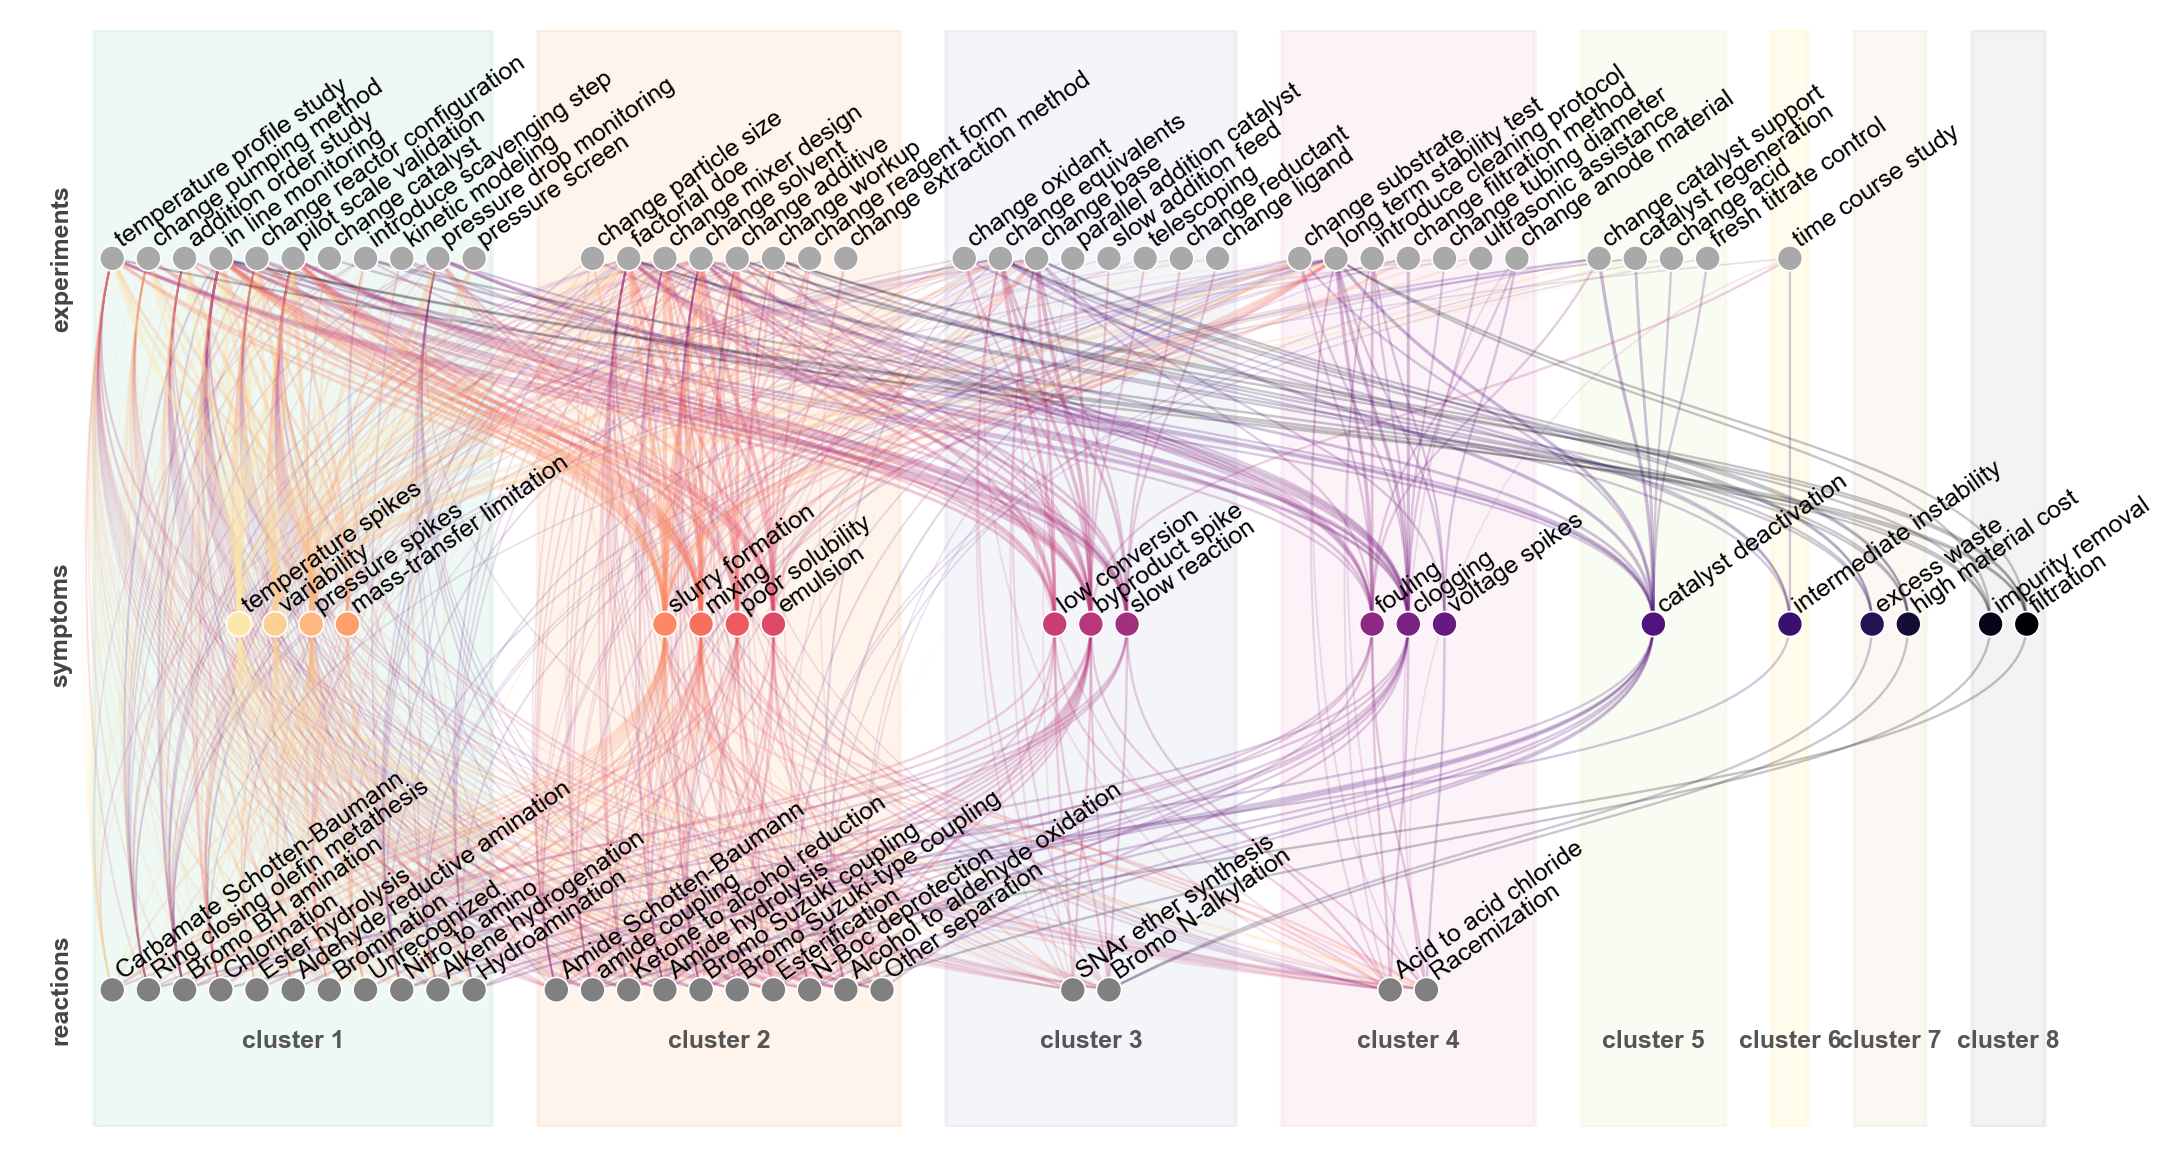

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.path import Path as MplPath
import networkx as nx
from collections import defaultdict
from scipy.cluster.hierarchy import linkage, fcluster
from experiment_map import exp_map, symptom_standard

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

all_reactions_rename = {
    "Carboxylic acid + amine condensation": "amide coupling",
    "Bromo Buchwald-Hartwig amination": "Bromo BH amination",
}

# ── data loading ───────────────────────────────────────────────────
data = pd.read_csv("symptoms_flat.csv")

new_rows = []
seen_symptoms = {}
for row_index, row in data.iterrows():
    seen_symptoms.setdefault(row_index, set())
    for symptom_name in row["Symptom"].split(" / "):
        normalized_symptom = symptom_standard.get(symptom_name, symptom_name)
        if normalized_symptom in seen_symptoms[row_index]:
            continue
        seen_symptoms[row_index].add(normalized_symptom)
        row_copy = row.copy()
        row_copy["Symptom"] = symptom_name
        row_copy["symptom_class"] = normalized_symptom
        new_rows.append(row_copy)

df = pd.DataFrame(new_rows)

fixed_hypotheses = []
experiment_classes = []
for _, row in df.iterrows():
    normalized_hypotheses = []
    for chunk in row["Hypothesis"].replace("\n", "").strip().split(", "):
        for token in chunk.split(" "):
            for candidate in token.split(","):
                if "_" not in candidate:
                    continue
                hypothesis_name = candidate.replace(".", "")
                if hypothesis_name == "gas_evolution_or_mass_transfer_management, pressure_or_gas_headspace_optimization, solvent_change_for_solubility, temperature_setpoint_or_temperature_ramp_optimization":
                    hypothesis_name = "gas_evolution_or_mass_transfer_management"
                if hypothesis_name == "custom_or_novel_reactor_design, improved_mixing_or_impeller_design, pressure_or_gas_headspace_optimization, temperature_setpoint_or_temperature_ramp_optimization":
                    hypothesis_name = "gas_evolution_or_mass_transfer_management"
                normalized_hypotheses.append(hypothesis_name)

    experiment_text = row["Experiment"].replace("\n", " ")
    experiment_classes.append(", ".join(sorted(exp_map[experiment_text])))
    fixed_hypotheses.append(", ".join(sorted(normalized_hypotheses)))

df["fixed_hypothesis"] = fixed_hypotheses
df["experiment_class"] = experiment_classes

# ── build digraph ──────────────────────────────────────────────────
dg = nx.DiGraph()
labels = {}
clade = {}

for reaction_name, reaction_df in df.groupby("reaction_split"):
    dg.add_node(reaction_name, count=len(reaction_df), depth=0)
    labels[reaction_name] = reaction_name
    clade[reaction_name] = "reaction_class"

    for symptom_name, symptom_df in reaction_df.groupby("symptom_class"):
        symptom_count = len(symptom_df)
        if dg.has_node(symptom_name):
            dg.nodes[symptom_name]["count"] += symptom_count
        else:
            dg.add_node(symptom_name, count=symptom_count, depth=1)
        labels[symptom_name] = symptom_name
        clade[symptom_name] = "symptom"

        if dg.has_edge(reaction_name, symptom_name):
            dg[reaction_name][symptom_name]["count"] += symptom_count
        else:
            dg.add_edge(reaction_name, symptom_name, count=symptom_count)

        for _, hypothesis_df in symptom_df.groupby("fixed_hypothesis"):
            for experiment_group, experiment_df in hypothesis_df.groupby("experiment_class"):
                experiment_count = len(experiment_df)
                for experiment_name in experiment_group.split(", "):
                    if not experiment_name:
                        continue
                    if dg.has_node(experiment_name):
                        dg.nodes[experiment_name]["count"] += experiment_count
                    else:
                        dg.add_node(experiment_name, count=experiment_count, depth=2)
                    labels[experiment_name] = experiment_name
                    clade[experiment_name] = "experiment"

                    if dg.has_edge(symptom_name, experiment_name):
                        dg[symptom_name][experiment_name]["count"] += experiment_count
                    else:
                        dg.add_edge(symptom_name, experiment_name, count=experiment_count)

                    # reaction → experiment shortcut
                    if dg.has_edge(reaction_name, experiment_name):
                        dg[reaction_name][experiment_name]["count"] += experiment_count
                    else:
                        dg.add_edge(reaction_name, experiment_name, count=experiment_count)

# ── partition into layers ──────────────────────────────────────────
symptom_nodes = [n for n, g in clade.items() if g == "symptom"]
reaction_nodes = [n for n, g in clade.items() if g == "reaction_class"]
experiment_nodes = [n for n, g in clade.items() if g == "experiment"]

layer_of = {}
for n in reaction_nodes:
    layer_of[n] = 0
for n in symptom_nodes:
    layer_of[n] = 1
for n in experiment_nodes:
    layer_of[n] = 2

# ══════════════════════════════════════════════════════════════════
#  CLUSTER SYMPTOMS BY NEIGHBOUR-WEIGHT SIMILARITY
# ══════════════════════════════════════════════════════════════════
_all_nb = sorted(set(reaction_nodes + experiment_nodes))
_nb_idx = {n: i for i, n in enumerate(_all_nb)}

_vectors = []
_sym_list = sorted(symptom_nodes)
for s in _sym_list:
    vec = np.zeros(len(_all_nb))
    for nb in nx.all_neighbors(dg, s):
        if nb in _nb_idx:
            w = (dg[s][nb].get("count", 1) if dg.has_edge(s, nb)
                 else dg[nb][s].get("count", 1))
            vec[_nb_idx[nb]] = w
    _vectors.append(vec)

X = np.array(_vectors)
_norms = np.linalg.norm(X, axis=1, keepdims=True)
_norms[_norms == 0] = 1
X = X / _norms

n_clusters = max(2, min(len(_sym_list) // 2, 8))
Z = linkage(X, method="ward")
_labels = fcluster(Z, t=n_clusters, criterion="maxclust")
symptom_cluster = {s: int(c) for s, c in zip(_sym_list, _labels)}

# ── assign reactions & experiments to dominant cluster ──────────────
def _dominant_cluster(node):
    weights = {}
    for nb in nx.all_neighbors(dg, node):
        if nb not in symptom_cluster:
            continue
        c = symptom_cluster[nb]
        w = (dg[node][nb].get("count", 1) if dg.has_edge(node, nb)
             else dg[nb][node].get("count", 1))
        weights[c] = weights.get(c, 0) + w
    return max(weights, key=weights.get) if weights else 1

node_cluster = dict(symptom_cluster)
for n in reaction_nodes:
    node_cluster[n] = _dominant_cluster(n)
for n in experiment_nodes:
    node_cluster[n] = _dominant_cluster(n)

# order clusters heaviest-left
cluster_ids = sorted(set(node_cluster.values()))
cluster_weight = {c: 0 for c in cluster_ids}
for n, c in node_cluster.items():
    cluster_weight[c] += dg.nodes[n].get("count", 0)
cluster_ids.sort(key=lambda c: cluster_weight[c], reverse=True)
cluster_rank = {c: i for i, c in enumerate(cluster_ids)}

# ══════════════════════════════════════════════════════════════════
#  WITHIN-CLUSTER BARYCENTER ORDERING
# ══════════════════════════════════════════════════════════════════
cl_layer_nodes = defaultdict(list)
for n in dg.nodes():
    cl_layer_nodes[(node_cluster[n], layer_of[n])].append(n)

for key in cl_layer_nodes:
    cl_layer_nodes[key].sort(
        key=lambda n: dg.nodes[n].get("count", 0), reverse=True)

local_idx = {}
for key, nodes in cl_layer_nodes.items():
    for i, n in enumerate(nodes):
        local_idx[n] = float(i)

for _sweep in range(16):
    for c in cluster_ids:
        for li in [0, 1, 2, 2, 1, 0]:
            nodes = cl_layer_nodes.get((c, li), [])
            if not nodes:
                continue
            adj_nodes = set()
            if li > 0:
                adj_nodes.update(cl_layer_nodes.get((c, li - 1), []))
            if li < 2:
                adj_nodes.update(cl_layer_nodes.get((c, li + 1), []))

            bary = {}
            for n in nodes:
                ws, ps = [], []
                for nb in nx.all_neighbors(dg, n):
                    if nb in adj_nodes:
                        w = (dg[n][nb].get("count", 1) if dg.has_edge(n, nb)
                             else dg[nb][n].get("count", 1))
                        ws.append(w)
                        ps.append(local_idx[nb])
                if ws:
                    tw = sum(ws)
                    bary[n] = sum(w * p for w, p in zip(ws, ps)) / tw
                else:
                    bary[n] = local_idx[n]

            nodes.sort(key=lambda n: bary[n])
            for i, n in enumerate(nodes):
                local_idx[n] = float(i)

# ══════════════════════════════════════════════════════════════════
#  POSITIONS:  x = across (clustered), y = down (by layer)
# ══════════════════════════════════════════════════════════════════
col_gap = 1.1
layer_gap = 3.2
cluster_gap = 2.5

pos = {}
x_cursor = 0.0
cluster_x_center = {}
cluster_x_bounds = {}

for ci, c in enumerate(cluster_ids):
    widths = {}
    for li in range(3):
        nodes = cl_layer_nodes.get((c, li), [])
        widths[li] = col_gap * max(len(nodes) - 1, 0)

    cluster_width = max(widths.values()) if widths else 0
    cluster_left = x_cursor

    for li in range(3):
        nodes = cl_layer_nodes.get((c, li), [])
        if not nodes:
            continue
        span = col_gap * max(len(nodes) - 1, 0)
        x_start = x_cursor + (cluster_width - span) / 2.0
        y = li * layer_gap
        for i, node in enumerate(nodes):
            pos[node] = (x_start + i * col_gap, y)

    cluster_right = x_cursor + cluster_width
    cluster_x_center[c] = (cluster_left + cluster_right) / 2.0
    cluster_x_bounds[c] = (cluster_left - col_gap * 0.5,
                           cluster_right + col_gap * 0.5)
    x_cursor = cluster_right + cluster_gap

# ══════════════════════════════════════════════════════════════════
#  NODE STYLING
# ══════════════════════════════════════════════════════════════════
node_colors = {}
node_labels = {}
for nn, ng in clade.items():
    if ng == "reaction_class":
        node_colors[nn] = "grey"
        node_labels[nn] = all_reactions_rename.get(
            labels[nn], labels[nn]).replace("_", " ")
    elif ng == "symptom":
        node_colors[nn] = "#E15759"
        node_labels[nn] = labels[nn].replace("_", " ")
    else:
        node_colors[nn] = "darkgrey"
        node_labels[nn] = labels[nn].replace("_", " ")

# per-symptom edge palette
_symptom_order = sorted(
    symptom_nodes,
    key=lambda s: (cluster_rank[node_cluster[s]], local_idx[s]), reverse=True)
_n_symp = len(_symptom_order)
_raw_colors = (
    [plt.cm.magma( i / 20) for i in range(min(_n_symp, 20))]
    + ([plt.cm.magma((i - 20) / 20) for i in range(20, _n_symp)]
       if _n_symp > 20 else [])
)
symptom_edge_color = {s: mcolors.to_hex(c)
                      for s, c in zip(_symptom_order, _raw_colors)}
for s, c in symptom_edge_color.items():
    node_colors[s] = c

# cluster band colours
_band_cmap = plt.cm.Pastel2
cluster_band_color = {
    c: mcolors.to_hex(
        _band_cmap(i / max(len(cluster_ids) - 1, 1)), keep_alpha=False)
    for i, c in enumerate(cluster_ids)
}

# ══════════════════════════════════════════════════════════════════
#  FIGURE + DRAWING
# ══════════════════════════════════════════════════════════════════
all_x = [x for x, _ in pos.values()]
all_y = [y for _, y in pos.values()]
fig_w = max(8, (max(all_x) - min(all_x)) * 1.0 + 4)
fig_h = max(5, (max(all_y) - min(all_y)) * 0.85 + 3)
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=300)

# ── cluster bands (vertical stripes) ──────────────────────────────
for c in cluster_ids:
    left, right = cluster_x_bounds[c]
    ax.axvspan(left, right,
               color=cluster_band_color[c], alpha=0.22, zorder=0)

# ── cluster titles above top layer ────────────────────────────────
for c in cluster_ids:
    cx = cluster_x_center[c]
    syms_in = cl_layer_nodes.get((c, 1), [])
    top_syms = sorted(
        syms_in,
        key=lambda s: dg.nodes[s].get("count", 0), reverse=True)[:3]
    tag = "\n".join(s.replace("_", " ") for s in top_syms)
    ax.text(cx, -0.55, f"cluster {cluster_rank[c] + 1}",
            ha="center", va="bottom", fontsize=6,
            fontweight="bold", color="#555555")
    # ax.text(cx, -0.30, tag,
    #         ha="center", va="bottom", fontsize=4.2,
    #         color="#888888", style="italic", linespacing=1.15)

# ── edges ─────────────────────────────────────────────────────────
bundle_strength = 0.45

# mediating symptom for cross-layer colour
_rx_exp_symptom = {}
for u, v in dg.edges():
    cu, cv = clade.get(u), clade.get(v)
    if cu == "reaction_class" and cv == "experiment":
        best_s, best_w = None, -1
        for s in dg.successors(u):
            if clade.get(s) == "symptom" and dg.has_edge(s, v):
                w = min(dg[u][s].get("count", 0), dg[s][v].get("count", 0))
                if w > best_w:
                    best_s, best_w = s, w
        _rx_exp_symptom[(u, v)] = best_s

for u, v in dg.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    w = dg[u][v].get("count", 1)
    cu, cv = clade.get(u), clade.get(v)
    is_cross = (cu == "reaction_class" and cv == "experiment")

    # colour by symptom
    if cu == "symptom":
        edge_color = symptom_edge_color.get(u, "#8D8D8D")
    elif cv == "symptom":
        edge_color = symptom_edge_color.get(v, "#8D8D8D")
    elif is_cross:
        med = _rx_exp_symptom.get((u, v))
        edge_color = (symptom_edge_color.get(med, "#B0B0B0")
                      if med else "#B0B0B0")
    else:
        edge_color = "#8D8D8D"

    if is_cross:
        # arc bowing left of both endpoints
        lw = 0.3 + 0.15 * np.log1p(w)
        alpha = min(0.10 + 0.04 * np.log1p(w), 0.28)
        xmid_arc = min(x0, x1) - 1.2
        ymid = (y0 + y1) / 2.0
        verts = [
            (x0, y0),
            (xmid_arc, y0 + (ymid - y0) * 0.4),
            (xmid_arc, y1 + (ymid - y1) * 0.4),
            (x1, y1),
        ]
    else:
        # adjacent-layer vertical bezier bundled toward symptom x
        lw = 0.4 + 0.25 * np.log1p(w)
        alpha = min(0.18 + 0.07 * np.log1p(w), 0.5)
        if cu == "symptom":
            xmid = x0
        elif cv == "symptom":
            xmid = x1
        else:
            xmid = (x0 + x1) / 2.0
        ymid = (y0 + y1) / 2.0
        cx0 = x0 + bundle_strength * (xmid - x0)
        cx1 = x1 + bundle_strength * (xmid - x1)
        verts = [
            (x0, y0),
            (cx0, ymid),
            (cx1, ymid),
            (x1, y1),
        ]

    codes = [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4]
    path = MplPath(verts, codes)
    patch = mpatches.FancyArrowPatch(
        path=path, arrowstyle="-",
        linewidth=lw, color=edge_color, alpha=alpha,
        zorder=0 if is_cross else 1,
    )
    ax.add_patch(patch)

# ── nodes ──────────────────────────────────────────────────────────
nx.draw_networkx_nodes(
    dg, pos, ax=ax, node_size=36,
    node_color=[node_colors[n] for n in dg.nodes()],
    linewidths=0.4, edgecolors="white",
)

# ── labels (angled, below each node) ──────────────────────────────
for nn, (x, y) in pos.items():
    ax.text(
        x, y + 0.22,
        node_labels[nn],
        fontsize=6, ha="left", va="top",
        rotation=35, rotation_mode="anchor",
        zorder=10,
    )

# ── layer labels on left margin ───────────────────────────────────
layer_names = {0: "reactions", 1: "symptoms", 2: "experiments"}
for li, name in layer_names.items():
    ax.text(min(all_x) - 1.2, li * layer_gap, name,
            ha="right", va="center", fontsize=6,
            fontweight="bold", color="#444444", rotation=90)

# ── axes ──────────────────────────────────────────────────────────
ax.set_xlim(min(all_x) - 2.5, max(all_x) + 2.5)
ax.set_ylim(-1.2, max(all_y) + 2.0)
ax.margins(0)
ax.set_axis_off()
fig.subplots_adjust(left=-0.01, right=0.98, top=0.995, bottom=-0.05)

plt.savefig("network_bundled.png", dpi=300, bbox_inches=None, pad_inches=0.01)
plt.savefig("network_bundled.pdf", bbox_inches="tight")
plt.show()

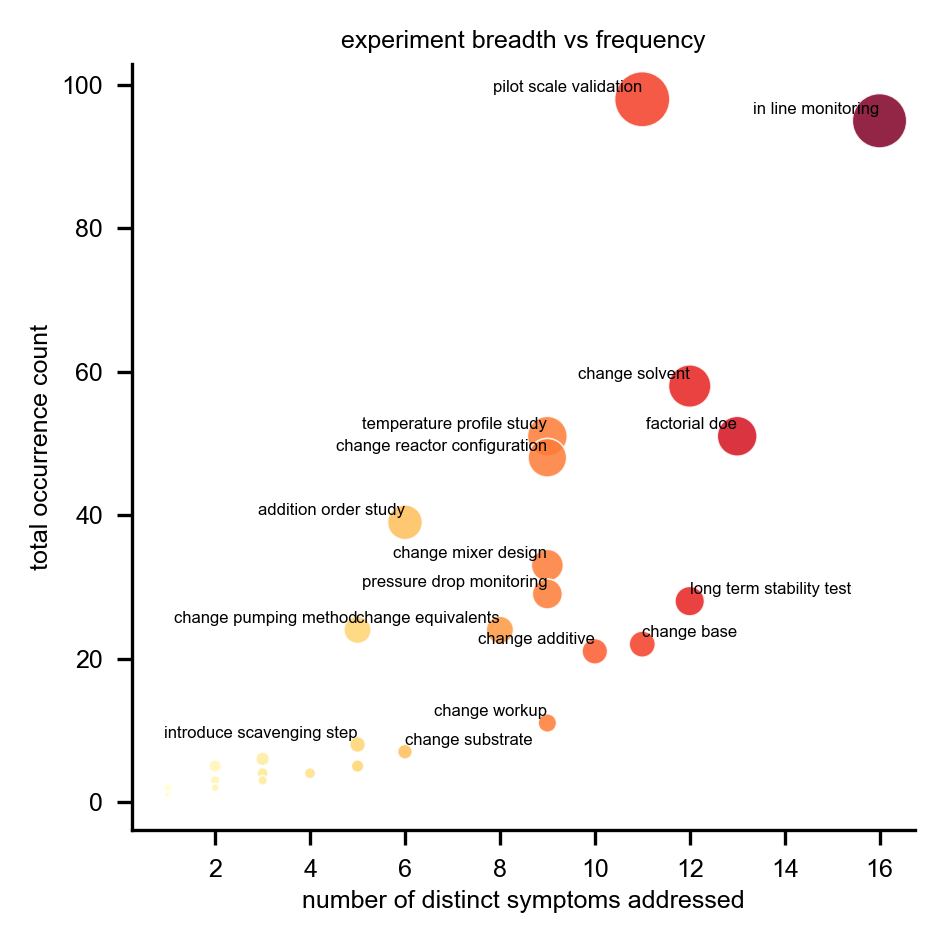

In [129]:
# Experiment solution breadth: distinct symptoms addressed vs total occurrences
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

exp_stats = {}
for symptom_name in symptom_nodes:
    for experiment_name in dg.successors(symptom_name):
        if clade.get(experiment_name) != "experiment":
            continue
        w = dg[symptom_name][experiment_name].get("count", 1)
        if experiment_name not in exp_stats:
            exp_stats[experiment_name] = {"symptoms": set(), "total": 0}
        exp_stats[experiment_name]["symptoms"].add(symptom_name)
        exp_stats[experiment_name]["total"] += w

names = sorted(exp_stats, key=lambda n: exp_stats[n]["total"], reverse=True)
breadth = np.array([len(exp_stats[n]["symptoms"]) for n in names])
totals = np.array([exp_stats[n]["total"] for n in names])
display_names = [n.replace("_", " ") for n in names]

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
sc = ax.scatter(
    breadth, totals,
    s=totals * 1.8,
    c=breadth, cmap="YlOrRd", edgecolors="white", linewidths=0.4,
    alpha=0.85, zorder=2,
)

# Label the top points by total count
for idx in np.argsort(-totals)[:17]:
    if display_names[idx] in ["long term stability test", "change base", "change substrate", "change oxidant"]: 
        ax.annotate(
            display_names[idx],
            (breadth[idx], totals[idx]),
            fontsize=4, ha="left", va="bottom",
            xytext=(0, 1), textcoords="offset points",
        )
    else:
        ax.annotate(
            display_names[idx],
            (breadth[idx], totals[idx]),
            fontsize=4, ha="right", va="bottom",
            xytext=(0, 1), textcoords="offset points",
        )

ax.set_xlabel("number of distinct symptoms addressed", fontsize=6, labelpad=2)
ax.set_ylabel("total occurrence count", fontsize=6, labelpad=2)
ax.set_title("experiment breadth vs frequency", fontsize=6, pad=4)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=6)
fig.subplots_adjust(left=0.12, right=0.99, top=0.95, bottom=0.1)

plt.savefig("plots/experiment_breadth_vs_frequency.png", dpi=300, bbox_inches=None, pad_inches=0.01)
plt.show()